In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


2023-09-11 13:48:24.869538: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
2023-09-11 13:48:27.544344: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Using backend: cpu

Available hardware:

TFRT_CPU_0

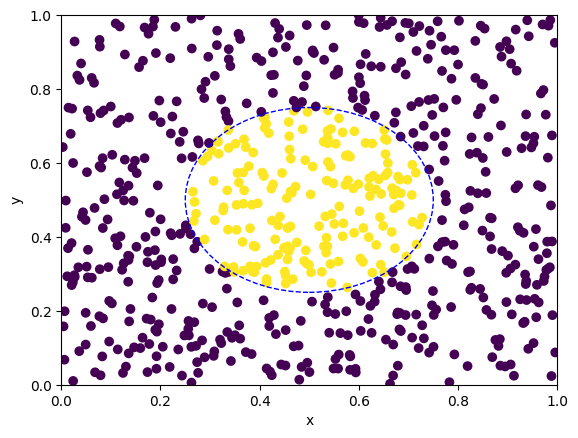

In [2]:
%run particle-insertion-modules.ipynb

In [3]:
@dataclass
class Measurement:
    width: int
    depth: int
    loss: np.ndarray
    trace: np.ndarray
    entropy: np.ndarray
    representations: np.ndarray
    loss_derivatives: np.ndarray
    class_entropy: dict

In [25]:
circle_results = np.load("circle/experiment-analysis.npy", allow_pickle=True)
linear_boundary_results = np.load("linear-boundary/experiment-analysis.npy", allow_pickle=True)
# linear_model_results = np.load("linear-model/experiment-analysis.npy", allow_pickle=True)

# Regime detection

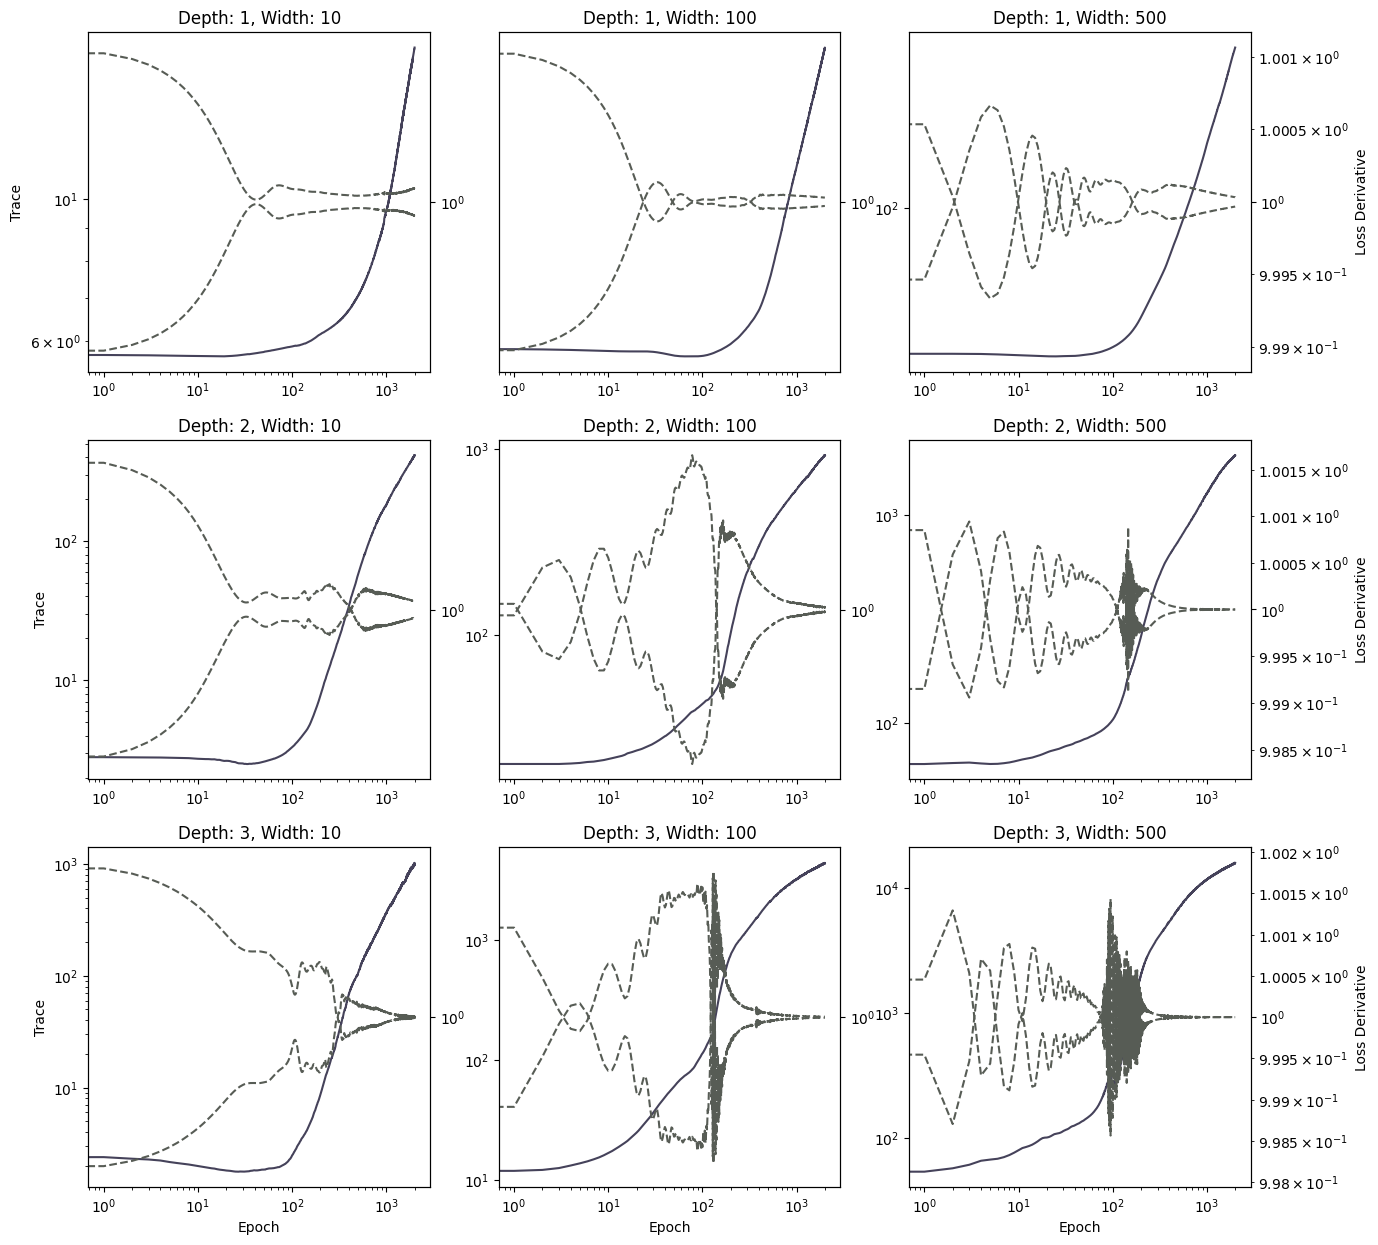

In [28]:
results = circle_results
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()

        y1_ax.plot(
            item[0].trace / 100, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.set_yscale("log")

        y2_ax.plot(
            item[0].loss_derivatives.mean(axis=1) + 1.0, 
            ls=linestyles[1],
            color=colours[1]
        )
        y2_ax.set_yscale("log")
        y2_ax.set_xscale("log")


        # y1_ax.set_xlim(0, 500)
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Trace")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("Loss Derivative")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/trace-ld.pdf", dpi=600)
plt.show()

/tmp/user/25266/ipykernel_421020/3639115360.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  y1_ax.set_xlim(0, 2000)


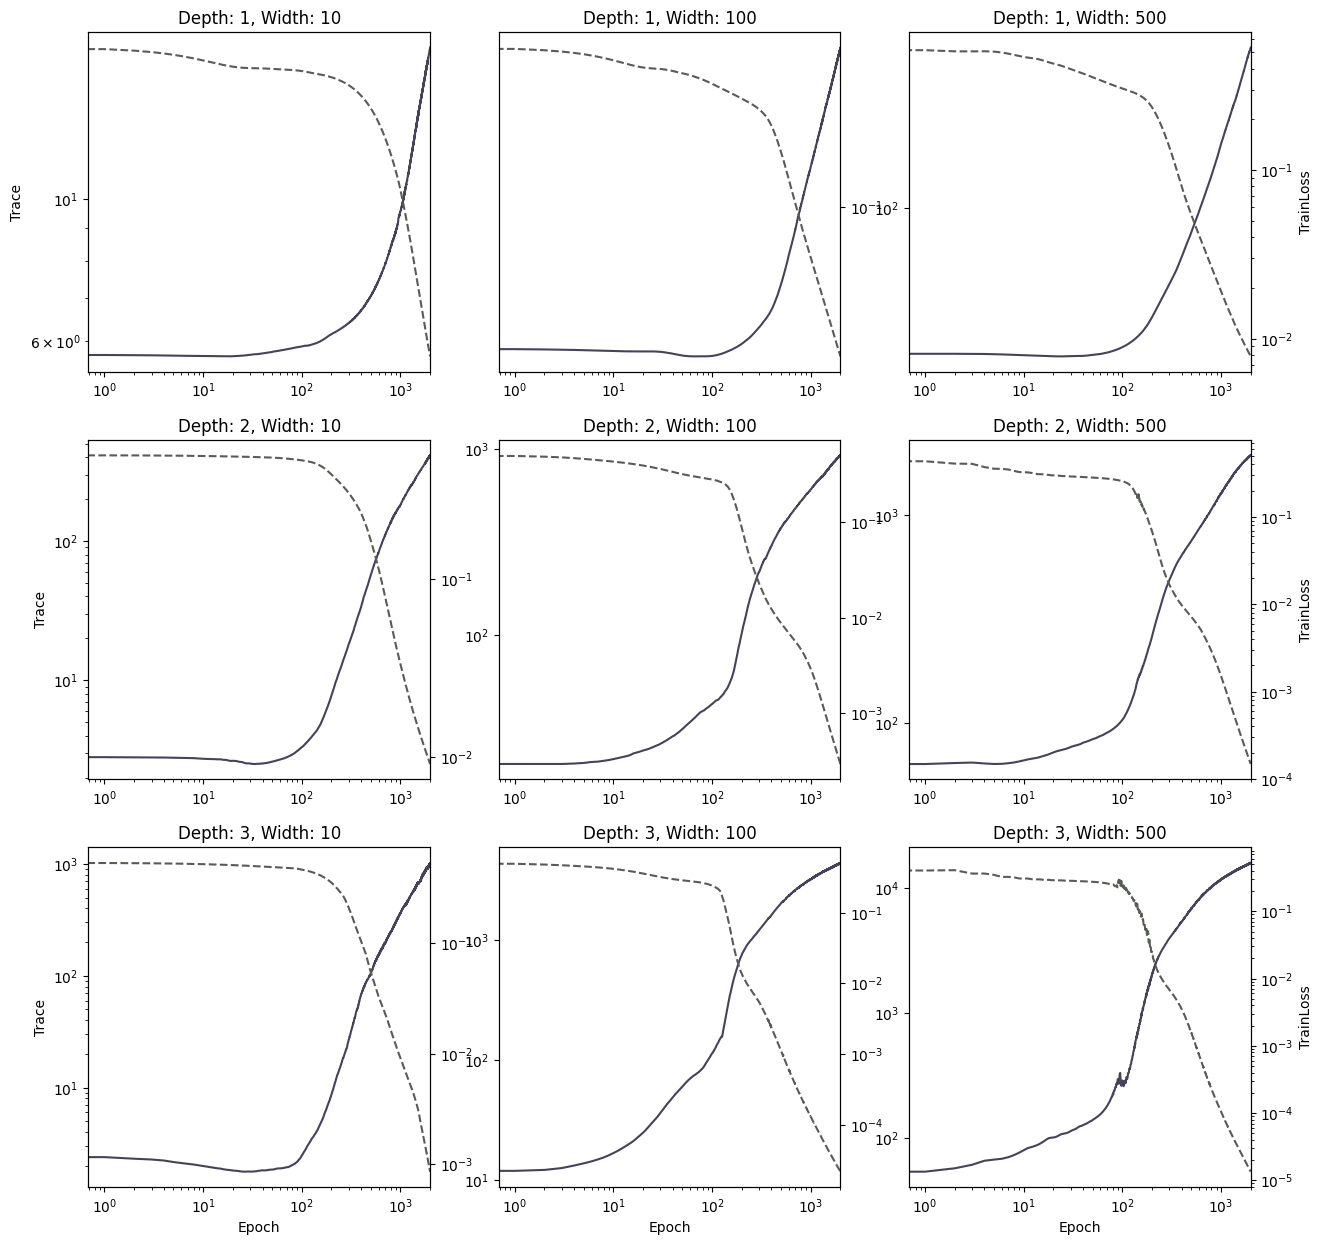

In [30]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()

        y1_ax.plot(
            item[0].trace / 100, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.set_yscale("log")
        y1_ax.set_yscale("log")

        y2_ax.plot(
            item[0].loss, 
            ls=linestyles[1],
            color=colours[1]
        )
        y2_ax.set_yscale("log")
        y2_ax.set_xscale("log")

        y1_ax.set_xlim(0, 2000)
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Trace")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("TrainLoss")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/trace-loss.pdf", dpi=600)
plt.show()

/tmp/user/25266/ipykernel_421020/3788476388.py:31: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  y1_ax.set_xlim(0, 2000)


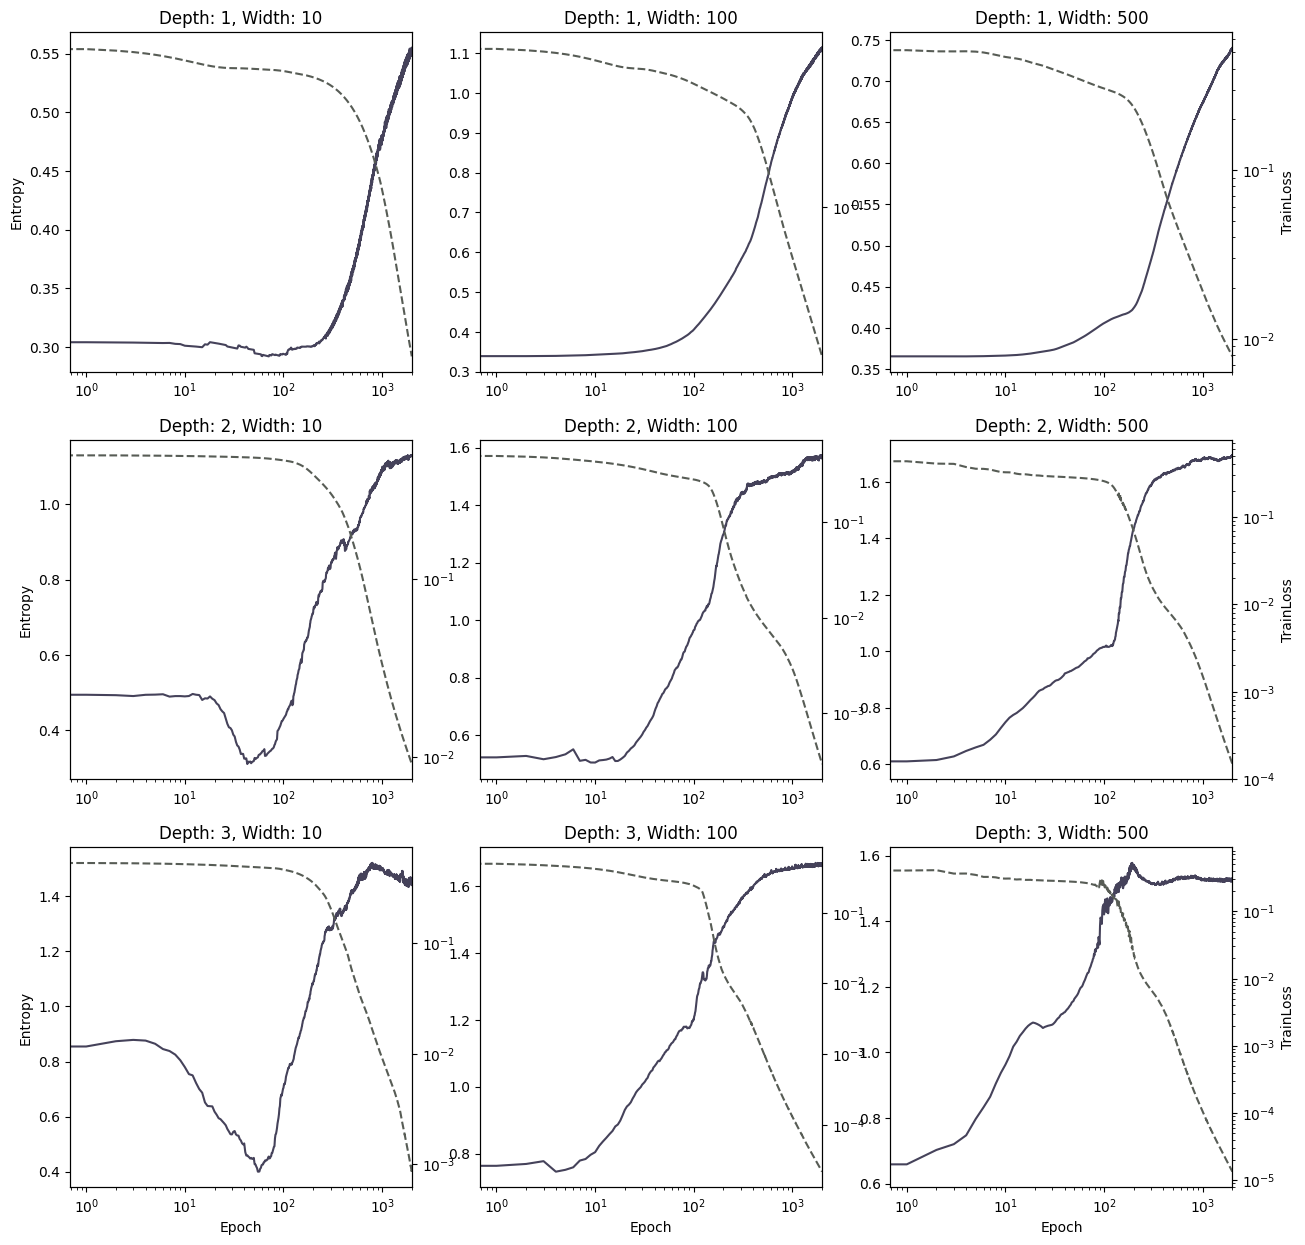

In [31]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()

        y1_ax.plot(
            item[0].entropy, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.set_xscale("log")

        y2_ax.plot(
            item[0].loss, 
            ls=linestyles[1],
            color=colours[1]
        )
        y2_ax.set_yscale("log")

        y1_ax.set_xlim(0, 2000)
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Entropy")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("TrainLoss")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/entropy-loss.pdf", dpi=600)
plt.show()

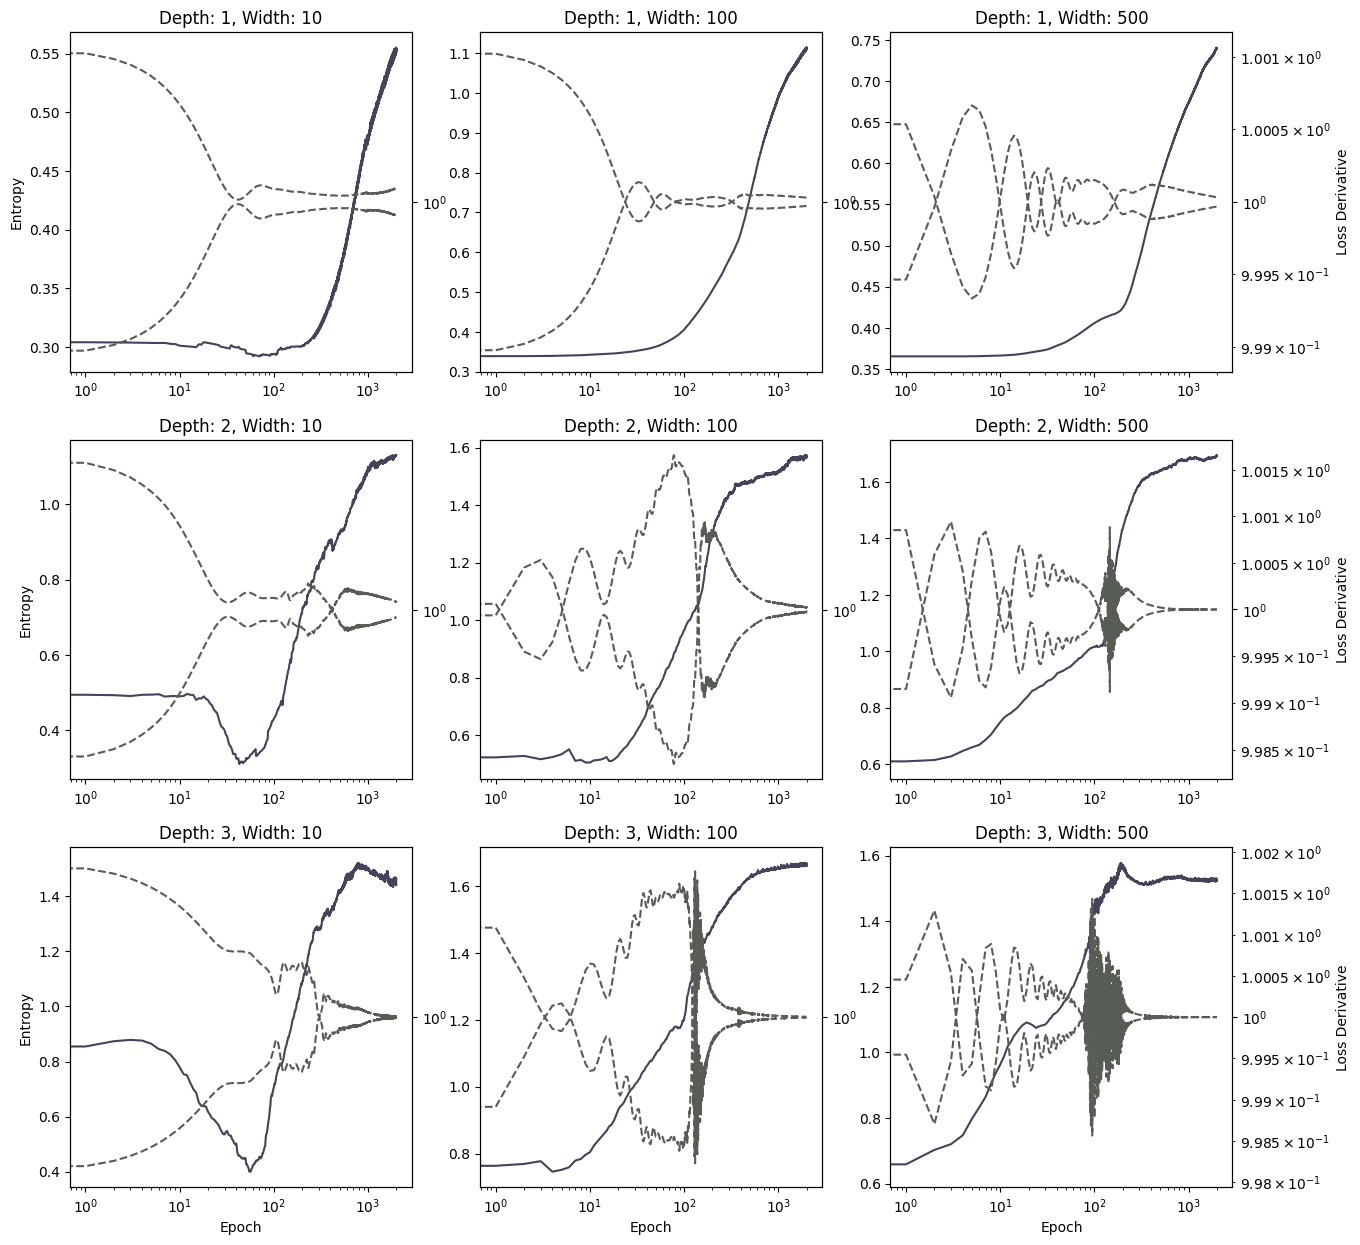

In [38]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()

        y1_ax.plot(
            item[0].entropy, 
            ls=linestyles[0],
            color=colours[0]
        )
#         y1_ax.set_yscale("log")

        y2_ax.plot(
            item[0].loss_derivatives.mean(axis=1) + 1.0, 
            ls=linestyles[1],
            color=colours[1]
        )
        y2_ax.set_yscale("log")

        y1_ax.set_xscale("log")
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Entropy")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("Loss Derivative")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/entropy-ld.pdf", dpi=600)
plt.show()

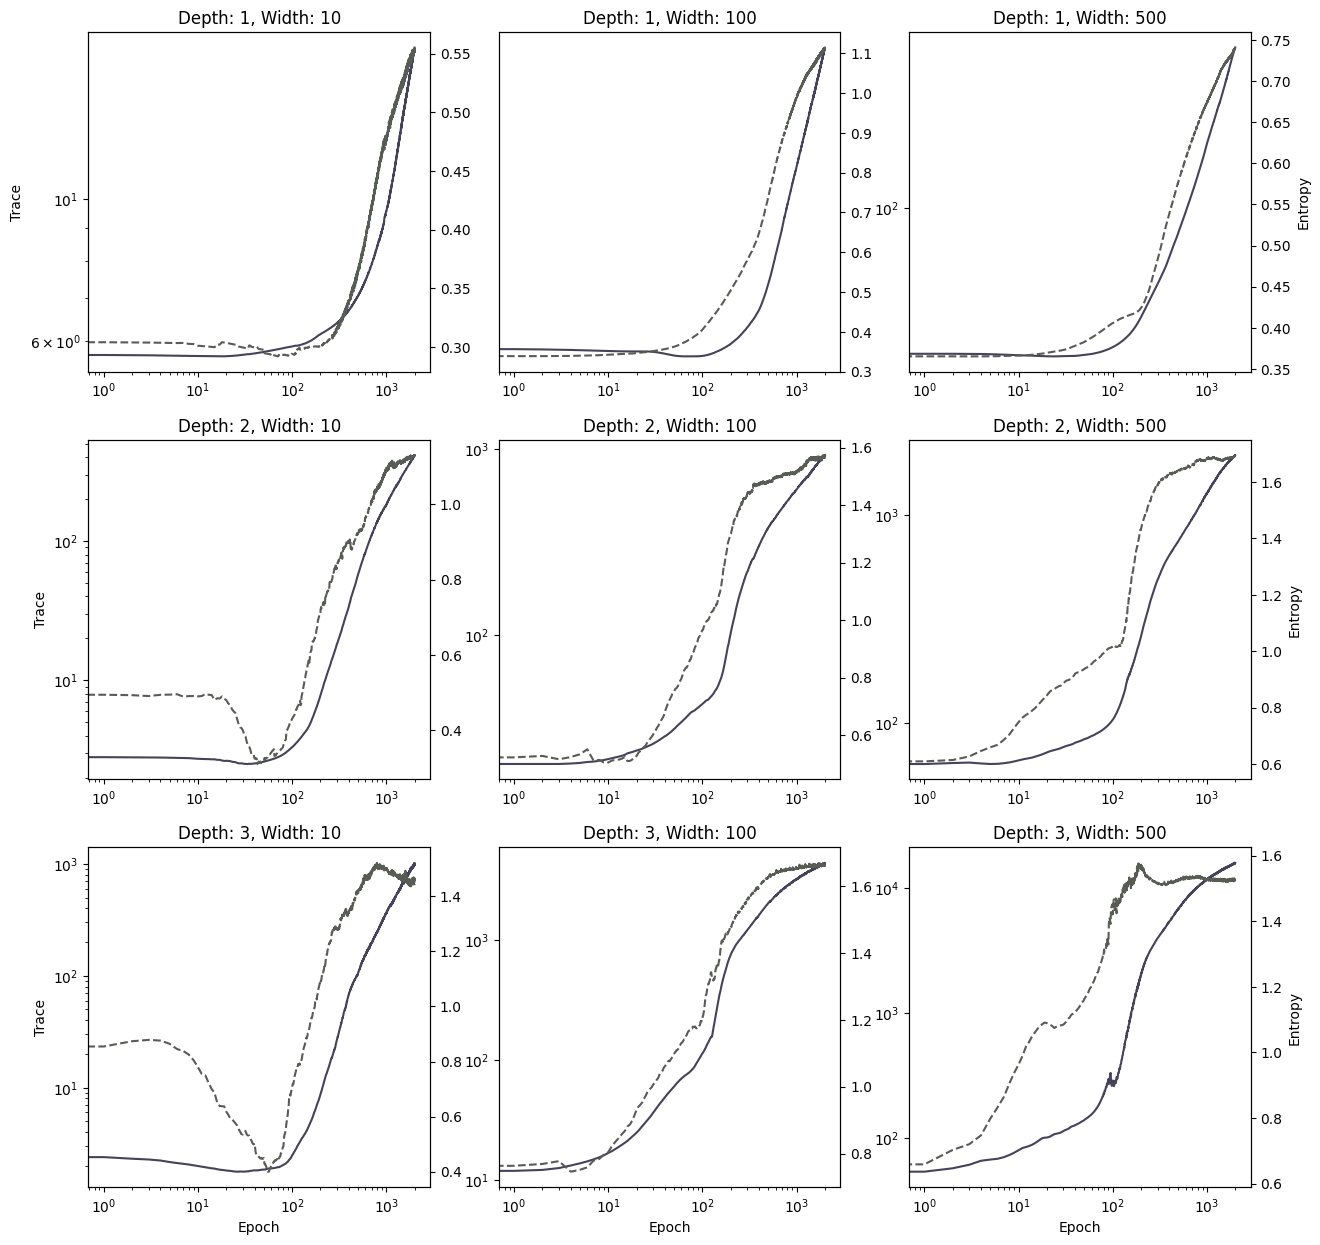

In [37]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()

        y1_ax.plot(
            item[0].trace / 100, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.set_yscale("log")

        y2_ax.plot(
            item[0].entropy, 
            ls=linestyles[1],
            color=colours[1]
        )
#         y2_ax.set_yscale("log")

        y1_ax.set_xscale("log")
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Trace")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("Entropy")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/trace-entropy.pdf", dpi=600)
plt.show()

/tmp/user/25266/ipykernel_421020/1906366213.py:46: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  y1_ax.set_xlim(0, 500)


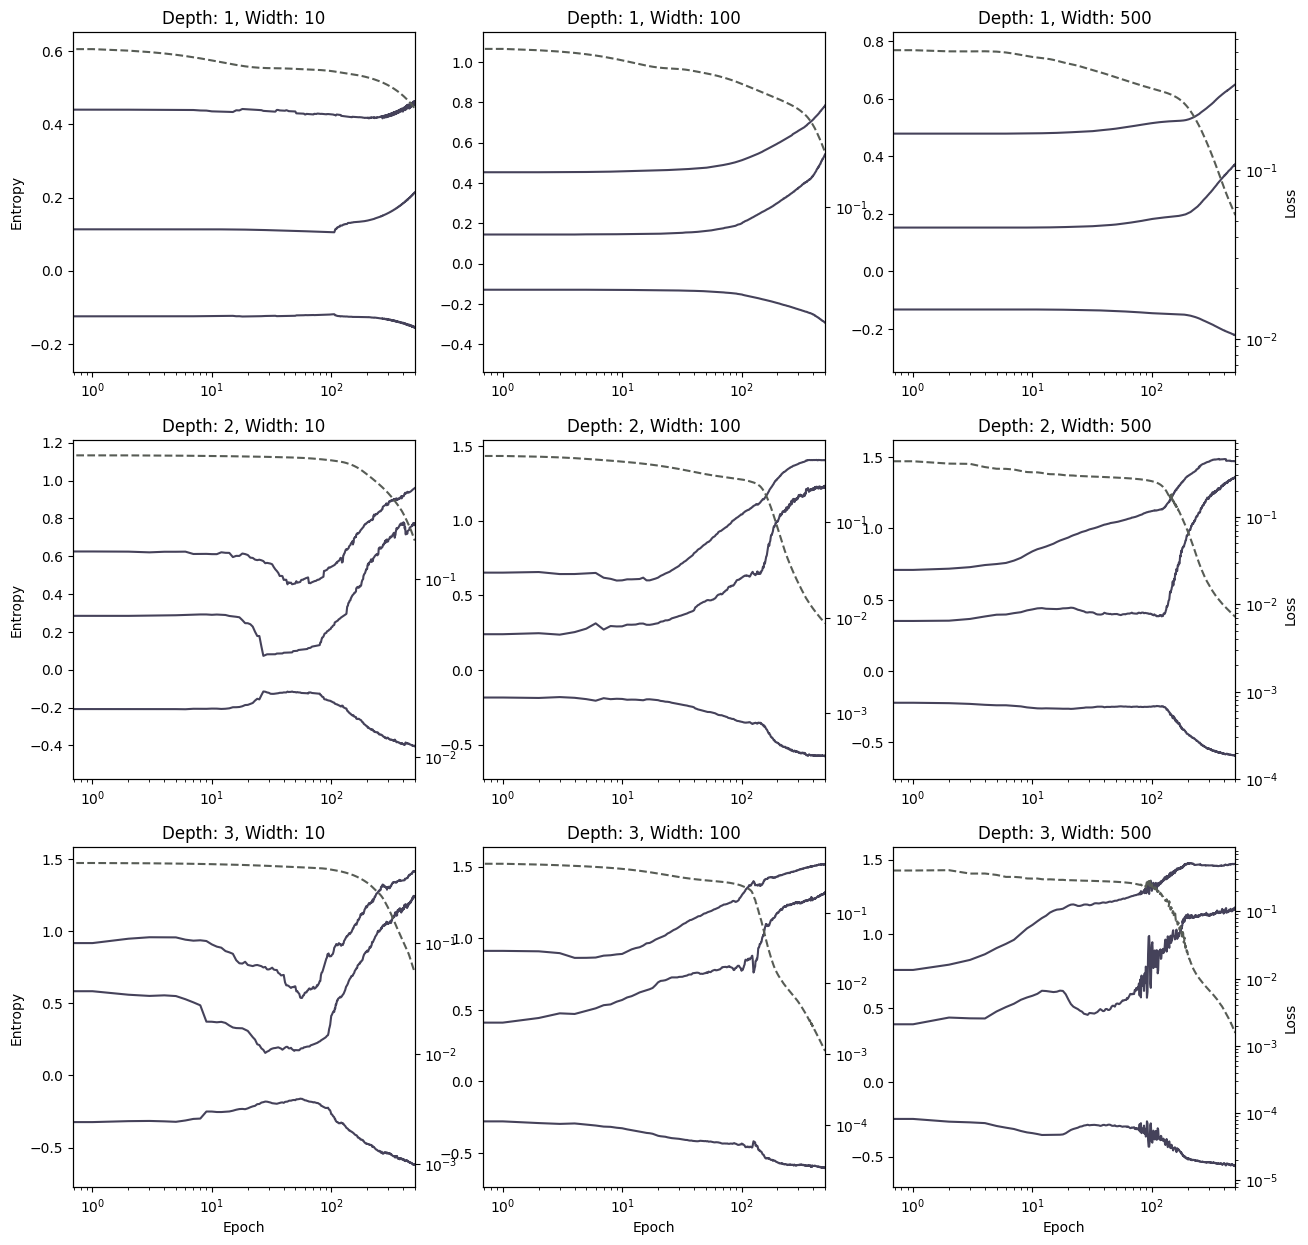

In [35]:
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

titles = [10, 100, 500]
linestyles = ["-", "--"]
colours = ["#45425A", "#575C55"]

for j, depth in enumerate([1, 2, 3]):
    data = [item for item in results if item.depth == depth]
    small = [item for item in data if item.width == 10]
    middle = [item for item in data if item.width == 100]
    large = [item for item in data if item.width == 500]

    for i, item in enumerate([small, middle, large]):
        y1_ax = ax[j, i]
        y2_ax = y1_ax.twinx()
        
        class_one_entropy = [subitem["one"] for subitem in item[0].class_entropy]
        class_two_entropy = [subitem["two"] for subitem in item[0].class_entropy]
        cross_entropy = [subitem["cross"] for subitem in item[0].class_entropy]

        y1_ax.plot(
            class_one_entropy, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.plot(
            class_two_entropy, 
            ls=linestyles[0],
            color=colours[0]
        )
        y1_ax.plot(
            cross_entropy, 
            ls=linestyles[0],
            color=colours[0]
        )

        y2_ax.plot(
            item[0].loss, 
            ls=linestyles[1],
            color=colours[1]
        )
        y2_ax.set_yscale("log")
        y2_ax.set_xscale("log")


        y1_ax.set_xlim(0, 500)
        
        if j == 2:
            y1_ax.set_xlabel("Epoch")

        if i == 0:
            y1_ax.set_ylabel("Entropy")
        else:
            y1_ax.set_yticks([], minor=True)
        if i == 2:
            y2_ax.set_ylabel("Loss")
        else:
            y2_ax.set_yticks([], minor=True)

        y1_ax.set_title(f"Depth: {depth}, Width: {titles[i]}")
        

plt.savefig("circle/class-entropy.pdf", dpi=600)
plt.show()